Clasificación Espectral I: Ecuaciones de Boltzmann y Saha
==

Alumno
---
Pedro G. Villegas

Docentes
---
J.P. Calderón & R. Gamen

Resumen
---

La Ecuación de Saha establece cual es la abundancia de iones de un elemento químico en cierto grado de ionización, con respecto a la abundancia de iones en un grado de ionización menor. Ese cociente depende de la temperatura del medio (T ) y de la presión de los electrones libres (Pe ):

\begin{equation}
        \frac{n_{i+1}}{n_i} = \frac{1}{n_e} \left( \frac{2 \pi m_e k T}{ h^2}
        \right)^{3/2} 2 \frac{\chi_{i+1}}{\chi_{i}} ~e^{-\frac{E_{ion}}{kT}} \nonumber
      \end{equation}

Suponiendo que el gas de electrones es un gas ideal, la presión es $P_{e} = n_{e} kT$ .
La Ecuación de Boltzmann, por otro lado, permite determinar la relación entre cantidades de un mismo átomo/especie según sus estados de excitación, en función de la temperatura:

\begin{equation}
    \frac{N_{j}}{N_i} = \frac{g_j}{g_i}~ e^{-\frac{E_{j}-E_{i}}{kT}} \nonumber
      \end{equation}
en donde el factor $g_{i}$ representa el estado de degeneración del nivel $i$.

Referencias
---
* [Práctica 05 (overleaf)](https://www.overleaf.com/read/khchztrfcnsq)

---

Ejercicios
---
Objetivos:
* Estudiar la abundancia química de un cierto elemento, en relación a las variables de estado de un gas ideal.

**1.** Variación de la Temperatura

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Defino las variables
x = np.arange ( 1000, 30000, 10 ) # Rango de T [K]

# Debo redefinir potenciales y otras cosas
k = 1.38E-23             # J/K
h = 6.63E-34             # J s
me = 9.11E-31            # kg 
E1 = 8.151683 * 1.60218e-19  # J
E2 = 16.34585 * 1.60218e-19  # J
E3 = 33.493 * 1.60218e-19    # J
E4 = 45.14179 * 1.60218e-19  # J
Pe = 10.0                  # N/m2 varía entre 0.1 a 100 (de frías a calientes) 1 dina/cm2 = 0.1 N/m2
#
# Defino funciones de partición
#
Si10=2./1.
Si21=2./1.
Si=2./1.
Si0=2./1.
Si32=2./1.
Si43=2./1.

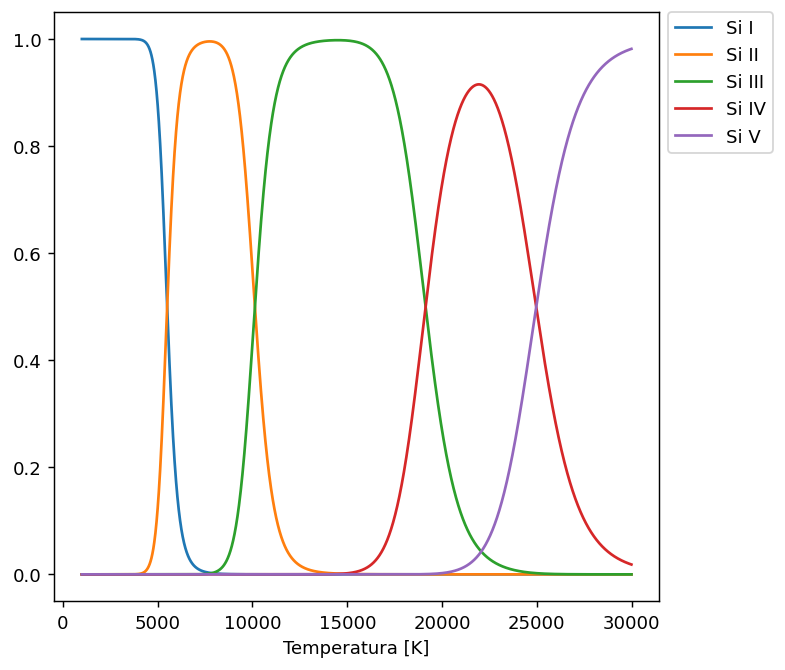

In [2]:
# Aplicación de la Ley de Saha
N10 = np.power ( 2*np.pi*me*k*x/(h*h),1.5) * np.exp(-E1/(k*x))*(Si10)*2*k*x/Pe
N21 = np.power ( 2*np.pi*me*k*x/(h*h),1.5) * np.exp(-E2/(k*x))*(Si21)*2*k*x/Pe
N32 = np.power ( 2*np.pi*me*k*x/(h*h),1.5) * np.exp(-E3/(k*x))*(Si32)*2*k*x/Pe
N43 = np.power ( 2*np.pi*me*k*x/(h*h),1.5) * np.exp(-E4/(k*x))*(Si43)*2*k*x/Pe

# Ecuaciones de recurrencia
N0T = 1.0 /(1.0 + N10 + N21 * N10 + N32 * N21 * N10 + N43 * N32 * N21 * N10  )
N1T = N10 * N0T
N2T = N21 * N10 * N0T
N3T = N32 * N21 * N10 * N0T
N4T = N43 * N32 * N21 * N10 * N0T

fig, ax = plt.subplots ( figsize = (6,6), dpi = 130 )
ax.plot ( x, N0T, label = 'Si I' )
ax.plot ( x, N1T, label = 'Si II' )
ax.plot ( x, N2T, label = 'Si III' )
ax.plot ( x, N3T, label = 'Si IV' )
ax.plot ( x, N4T, label = 'Si V' )
# Agregar el resto de los cocientes --> cocientes agregados ;)

ax.set_xlabel('Temperatura [K]')

plt.legend ( bbox_to_anchor = (1, 1.015), loc = 'upper left')
plt.show()

**2.** La ley de Saha y los tipos espectrales

In [3]:
xmax1 = x [ np.argmax ( N0T ) ]
print ('El SiI tiene máximo en:', xmax1, 'K')
xmax2 = x [ np.argmax ( N1T ) ]
print ('El SiII tiene máximo en:', xmax2, 'K')
xmax3 = x [ np.argmax ( N2T ) ]
print ('El SiIII tiene máximo en:', xmax3, 'K')
xmax4 = x [ np.argmax ( N3T ) ]
print ('El SiIV tiene máximo en:', xmax4, 'K')
xmax5 = x [ np.argmax ( N4T ) ]
print ('El SiV tiene máximo en:', xmax5, 'K')

El SiI tiene máximo en: 1000 K
El SiII tiene máximo en: 7740 K
El SiIII tiene máximo en: 14500 K
El SiIV tiene máximo en: 21940 K
El SiV tiene máximo en: 29990 K


**3.** Aplicación de la Ley de Saha

Compare una estrella G5 III y una G5 V. Suponga que la presión y temperatura en las atmósferas de dichas estrellas son:

           CL     T [K]        Pe [barias]
          III     4700          1
           V      5400         20

y calcule la ionización del hierro (Fe) y estroncio (Sr),
usando los siguientes datos:

       Elemento   Eion [ev]      χ0         χ1
       Fe         7.87           25         30
       Sr         5.69            1          2

Comente cómo puede utilizarse el resultado obtenido en el punto anterior para la clasificación espectral.


In [4]:
# Para la estrella G5III
PeIII = 0.1       #N/m^2
TIII = 4700       #Kelvin

# Para la estrella G5V
PeV = 2           #N/m^2 --------------> 1baria = 1dina/cm^2 = 0.1 N/m^2
TV = 5400         #Kelvin

# Funciones de partición
Fe10 = 30./25.
Sr10 = 2./1.

# Energías de los estados de ionización
EFe = 7.87 * 1.60218e-19 #J ----> El segundo término es la equivalencia eV a J
ESr = 5.69 * 1.60218e-19 #J

NFeIII = np.power ( 2*np.pi*me*k*TIII/(h*h),1.5) * np.exp(-EFe/(k*TIII))*(Fe10)*2*k*TIII/PeIII
NSrIII = np.power ( 2*np.pi*me*k*TIII/(h*h),1.5) * np.exp(-ESr/(k*TIII))*(Sr10)*2*k*TIII/PeIII

NFeV = np.power ( 2*np.pi*me*k*TV/(h*h),1.5) * np.exp(-EFe/(k*TV))*(Fe10)*2*k*TV/PeV
NSrV = np.power ( 2*np.pi*me*k*TV/(h*h),1.5) * np.exp(-ESr/(k*TV))*(Sr10)*2*k*TV/PeV

Fe = np.log10(NFeIII) - np.log10(NFeV)
Sr = np.log10(NSrIII) - np.log10(NSrV)

print ('Ionización del Hierro G5III=', NFeIII)
print ('Ionización del Estroncio G5III= ', NSrIII)
print()
print ('Ionización del Hierro G5V=', NFeV)
print ('Ionización del Estroncio G5V= ', NSrV)
print()
print('Logaritmos Hierro = ', Fe)
print('Logaritmos Estroncio = ', Sr)

Ionización del Hierro G5III= 4.35738735554646
Ionización del Estroncio G5III=  1584.0847914929839

Ionización del Hierro G5V= 3.8316899804790583
Ionización del Estroncio G5V=  693.0703975549915

Logaritmos Hierro =  0.05583580547121958
Logaritmos Estroncio =  0.3590010747640662


In [5]:
# Resolución de Juampi

TIII =4700 #K
TV = 5400 #K
PIII= 0.1 #N/m**2
PV = 2 #N/m**2

EionFe = 1.260913e-18 #J
EionSr = 9.11638e-19 #J 

U0Fe = 25
U1Fe = 30
U0Sr = 1
U1Sr = 2

Fe10 = U1Fe/U0Fe

Sr10 = U1Sr/U0Sr

N10FeV = np.power ( 2*np.pi*me*k*TV/(h*h),1.5) * np.exp(-EionFe/(k*TV))*(Fe10)*2*k*TV/PV

N10FeIII = np.power ( 2*np.pi*me*k*TIII/(h*h),1.5) * np.exp(-EionFe/(k*TIII))*(Fe10)*2*k*TIII/PIII

N10SrV = np.power ( 2*np.pi*me*k*TV/(h*h),1.5) * np.exp(-EionSr/(k*TV))*(Sr10)*2*k*TV/PV

N10SrIII = np.power ( 2*np.pi*me*k*TIII/(h*h),1.5) * np.exp(-EionSr/(k*TIII))*(Sr10)*2*k*TIII/PIII

RFe = np.log10(N10FeIII) - np.log10(N10FeV)

RSr = np.log10(N10SrIII) - np.log10(N10SrV)

print('Hierro = ', RFe)
print('Estroncio = ', RSr)

Hierro =  0.05583811430827412
Estroncio =  0.35900317528499537


**4.** Una atmósfera de puro H

Considere una atmósfera estelar constituida completamente por hidrógeno. Calcule y grafique la fracción de átomos neutros con electrones en el estado $n = 2$ (N2), respecto del total de átomos neutros e ionizados (N$_{total}$ = HI + HII). 

Considere: $g_n$ = 2$n^2$, $P_e$ = 200 bar.
Compare con la Fig. 1. ¿A qué temperatura se da el máximo de la curva y con cuál tipo espectral puede asociarlo? Explique qué fenómeno domina hacia
temperaturas mayores y cuál, hacia menores.


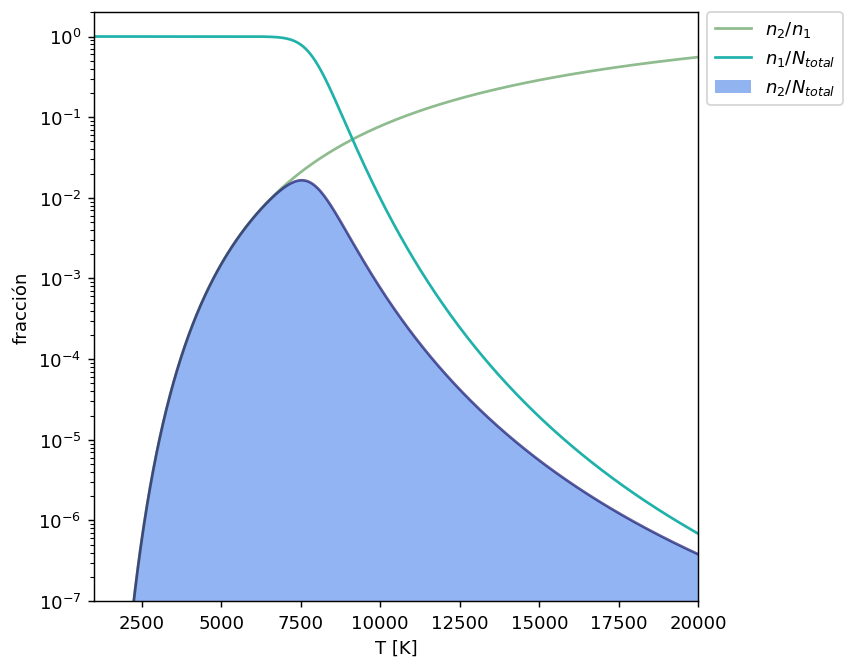

In [54]:
#%matplotlib notebook
x = np.arange ( 1000, 200000, 10 ) # Temperatura

k = 1.3806504E-16    # erg K^-1 
h = 6.62606896E-27   # erg s 
me = 9.10938291E-28  # gr
pe = 20.             # barias
conv = 1.60218e-12 # 1ev == 1.60218e-12 erg

# Cuando hay Boltzmann hay estados excitados (g habla de los nºs cuánticos).
# Cuando hay Saha, hay ionización
X21 = 2./1.
Xi = 13.54 *conv  # eV*conv = erg
saha = np.power( 2*np.pi*me*k*x/(h*h),1.5) * np.exp(-Xi/(k*x))*(X21)*2*k*x/pe

g21 = 8./2.
E2 = 3.40*conv
#Hidrógeno excitado (n2) respecto del Hidrógeno neutro
bolt = g21 * np.exp(-E2/(k*x)) #En verde

# Fracción de átomos neutros respecto del total (neutro, excitado e ionizado)
neutros = 1.0 / ( 1.0 + saha ) #en turquesa

# Fracción de átomos de H exitados (con electrones en nivel 2) respecto del total (neutros, excitados e ionizados) 
N2 = bolt*neutros #En azul

fig, ax1 = plt.subplots ( 1,1, figsize = (6,6), dpi = 130 )
ax1.plot ( x, bolt, color = 'darkseagreen', label = '$n_2/n_1$' )
ax1.plot ( x, neutros, color = 'lightseagreen', label = '$n_1/N_{total}$' )
ax1.plot ( x, N2, color = 'midnightblue', alpha = 0.7)
ax1.fill_between ( x, 0, N2, facecolor = 'cornflowerblue', alpha = 0.7, label = '$n_2/N_{total}$' )

ax1.set_xlabel('T [K]')
ax1.set_ylabel('fracción')

ax1.set_xlim ( 1000, 20000 )
ax1.set_ylim ( 1E-7, 2 )
ax1.set_yscale ( 'log' )

plt.legend ( bbox_to_anchor = (1, 1.015), loc = 'upper left')
plt.show()